In [1]:
# Bibliotecas   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# caminho do arquivo
data = '../data/raw/CC_GENERAL.csv'

# ler arquivo e gerar o df
df_credit_card = pd.read_csv(data)

In [3]:
# Analisar o df
df_credit_card.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


**CUST_ID** : ID do titular - Categórica  
**BALANCE** : Saldo devedor atual  
**BALANCE_FREQUENCY** : Com que frequencia o saldo devedor é atualizado? Entre 0 e 1 (1 = frequently updated, 0 = not frequently updated)  
**PURCHASES** : Valor de compras feitas na conta  
**ONEOFF_PURCHASES** : Valor máximo de compra realizado a vista  
**INSTALLMENTS_PURCHASES** : Valor de compra feita em parcelas  
**CASH_ADVANCE** : Valor retirado em pagamentos antecipados (emprestimos, saques)  
**PURCHASES_FREQUENCY** : Com que frequencia as compras tem sendo feitas? Entre 0 e 1 (1 = frequently purchased, 0 = not frequently purchased)  
**ONEOFFPURCHASESFREQUENCY** : Com que frequencia as compras são a vista? (1 = frequently purchased, 0 = not frequently purchased)  
**PURCHASESINSTALLMENTSFREQUENCY** : Com que frequencia as compras parceladas são feitas (1 = frequently done, 0 = not frequently done)  
**CASHADVANCEFREQUENCY** : Com que frequencia o emprestimo/saque é feito  
**CASHADVANCETRX** : Qntd de emprestimos/saque  
**PURCHASES_TRX** : Qntd de transacoẽs de compras feitas  
**CREDIT_LIMIT** : Limite do cartão de credito para o usuário  
**PAYMENTS** : Valor do pagamento tt  
**MINIMUM_PAYMENTS** : Valor minimo da fatura  
**PRCFULLPAYMENT** : Percental de pagamento tt (1=sempre quitou, 0 = nunca quitou tudo)  
**TENURE** : Tempo de contrato (meses) 

In [4]:
df_credit_card.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
df_credit_card.drop_duplicates(inplace= True)

In [6]:
def renomear_coluna(df):
    for i in df.columns:
        df.rename(
            columns = {i: i.lower()},
            inplace = True
        )

In [7]:
renomear_coluna(df_credit_card)
df_credit_card.columns

Index(['cust_id', 'balance', 'balance_frequency', 'purchases',
       'oneoff_purchases', 'installments_purchases', 'cash_advance',
       'purchases_frequency', 'oneoff_purchases_frequency',
       'purchases_installments_frequency', 'cash_advance_frequency',
       'cash_advance_trx', 'purchases_trx', 'credit_limit', 'payments',
       'minimum_payments', 'prc_full_payment', 'tenure'],
      dtype='str')

### 1.1) Analise das distribuição

In [8]:
df_credit_card.describe()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### 1.2) Analise de quartis

In [9]:
# Funcão para analisar e gerar boxsplot
def quartis(df):
    linhas_df = []

    for col in df.select_dtypes(include='number').columns:
        # if df[col].dtype != 'object' or ~isinstance(col, str):
        Q1 = df[col].quantile(q = 0.25)
        Q3 = df[col].quantile(q = 0.75)

        DQ = Q3 - Q1

        LS = round(Q3 + 1.5*DQ, 2)
        LI = round(Q1 - 1.5*DQ, 2)

        acima = len(df[df[col] > LS])
        abaixo = len(df[df[col] < LI])

        if acima > 0 or abaixo > 0:
            linhas_df.append({
                'Coluna': col,
                'LS': LS,
                'Acima': acima,
                'LI': LI,
                'Abaixo': abaixo
            })
        
    # Gerar um df com as informações
    return pd.DataFrame(linhas_df)

In [10]:
quartis(df_credit_card)

,Coluna,LS,Acima,LI,Abaixo
0,balance,4942.93,695,-2760.51,0
1,balance_frequency,1.17,0,0.72,1493
2,purchases,2715.87,808,-1566.11,0
3,oneoff_purchases,1443.51,1013,-866.11,0
4,installments_purchases,1171.59,867,-702.96,0
5,cash_advance,2784.55,1030,-1670.73,0
6,oneoff_purchases_frequency,0.75,782,-0.45,0
7,cash_advance_frequency,0.56,513,-0.33,0
8,cash_advance_trx,10.00,804,-6.00,0
9,purchases_trx,41.00,766,-23.00,0


Apesar de haver colunas com varios registros acima do superior e até mesmo abaixo do limite inferior, não podemos tratar esses registros como outliers dado o tipo de negocio do dataset que estamos analisando.Esses dados atipicos, são dados essenciais para uma boa predição.  

Nas informações do dataset, todas as variáveis de frequencias foram descritas variando entre 0 e 1.  
Porém, cash_advance_frequency está com um registro max de 1.5, conforme apresentando no .describe().  
Para entender melhor e garantir uma boa EDA veremos se os dados com valor > 1 tem algum padrão ou podem indicar algo.

In [11]:
df_analysis = df_credit_card[df_credit_card['cash_advance_frequency'] > 1]
df_analysis 

,cust_id,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
681,C10708,5656.069801,1.000000,362.36,362.36,0.0,7240.433194,0.250000,0.250000,0.0,1.250000,12,2,8000.0,683.421497,2036.877611,0.0,8
1626,C11680,2876.009336,1.000000,152.61,152.61,0.0,3719.650168,0.333333,0.333333,0.0,1.166667,24,2,4000.0,248.342971,584.926336,0.0,6
2555,C12629,5906.184924,1.000000,141.80,141.80,0.0,1651.286918,0.125000,0.125000,0.0,1.125000,12,2,10000.0,933.969974,919.289675,0.0,8
2608,C12684,7801.511533,1.000000,231.40,231.40,0.0,4109.465221,0.100000,0.100000,0.0,1.100000,20,3,13500.0,1593.617739,1522.496755,0.0,10
3038,C13127,3846.742530,1.000000,0.00,0.00,0.0,1932.460679,0.000000,0.000000,0.0,1.500000,18,0,5600.0,496.245836,538.346874,0.0,6
3253,C13347,5709.486507,0.833333,0.00,0.00,0.0,2794.326341,0.000000,0.000000,0.0,1.166667,10,0,6000.0,550.513331,1299.463370,0.0,6
8055,C18273,1917.895730,1.000000,285.07,285.07,0.0,6084.858872,0.363636,0.363636,0.0,1.090909,28,6,3000.0,5692.682993,556.449635,0.0,11
8365,C18588,3857.562230,1.000000,0.00,0.00,0.0,2127.213754,0.000000,0.000000,0.0,1.142857,26,0,5000.0,617.508991,538.396872,0.0,7


Analisando usuários com frequencia de emprestimos/saques maiores que 1, ou seja, nota-se que fazem parte dos mesmo que até o momento não fizeram o pagamento integral

### 1.3) Tratamento dos nulos

In [12]:
# verificar qtde de nulo
nulos = df_credit_card.isnull().sum()
nulos = nulos[nulos > 0] 
nulos

credit_limit          1
minimum_payments    313
dtype: int64

Há duas variaveis com valores nulos, porém a quantidade de ausentes em cada uma delas é muito diferentes.  
Logo, para credit_card é justo aplicar a substituição do nulo pela mediana.  
Enquanto que, para o minimiu_pay, se fizermos o mesmo, varios registros terão dados semelhantes o que pode impactar na predição do modelo (achar que existe um padrão). 
Para minimium_pay será aplicado a técnica Missing Indicator, onde fazemos a substituição pela mediana mas também criamos uma nova variável booleana que irá indicar a ausência do dado original

In [13]:
# Calculo da mediana
mediana_credit = df_credit_card['credit_limit'].median()

mediana_min_pay = df_credit_card['minimum_payments'].median()

In [14]:
# Criar coluna booleana a respeito de minimum_payments
df_credit_card['null_minimum_payments'] = df_credit_card['minimum_payments'].isnull()

# Substituir nulos pela mediana
df_credit_card['credit_limit'] = df_credit_card['credit_limit'].fillna(mediana_credit)

df_credit_card['minimum_payments'] = df_credit_card['minimum_payments'].fillna(mediana_min_pay)

# verificar qtde de nulo
nulos = df_credit_card.isnull().sum()
nulos = nulos[nulos > 0] 
nulos

Series([], dtype: int64)

### 1.4) Analise de correlação
Analise previa para entender as possíveis relação ou multicolenearidade entre as variáveis.  
Existem dos coeficientes possiveis para essa analise:  
* Person: Mede a relação linear entre duas variáveis, sendo sensivel a escalas diferentes e outliers.  
* Spearman: Mede a relação entre as variáveis sem precisa que sejam lineares.  

Em razão de haver muitos outliers, vamos optar por **Spearman**

In [15]:
df_credit_card.columns

Index(['cust_id', 'balance', 'balance_frequency', 'purchases',
       'oneoff_purchases', 'installments_purchases', 'cash_advance',
       'purchases_frequency', 'oneoff_purchases_frequency',
       'purchases_installments_frequency', 'cash_advance_frequency',
       'cash_advance_trx', 'purchases_trx', 'credit_limit', 'payments',
       'minimum_payments', 'prc_full_payment', 'tenure',
       'null_minimum_payments'],
      dtype='str')

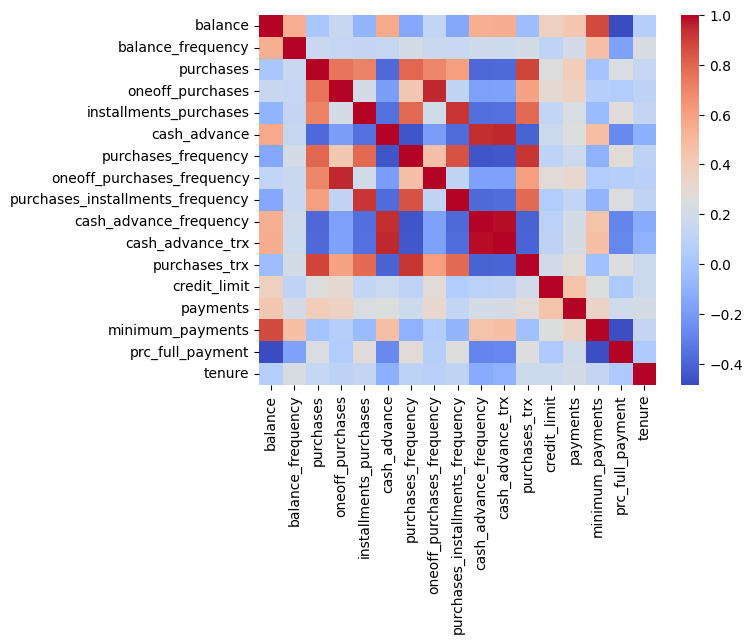

In [20]:
# analisando o df sem as categoricas
df_corr = df_credit_card.drop(columns=['cust_id', 'null_minimum_payments'])

#calculando a correlacao Spearman
corr_spearman = df_corr.corr(method= 'spearman')

#grafico de correlacao
sns.heatmap(
    corr_spearman, annot=False, cmap='coolwarm'
)
plt.show()

Analisando as correlações podemos afirmar que:  
* Relação positiva (ambas variáveis aumentam juntas)  
balance + minimum_payments  

* Relação negativa (conforme uma aumenta a outra diminui)  
balance - prc_full_payments  
minimum_payments - prc_full_payments  
cash_advance - purchases  

De modo resumido, o saldo devedor aumenta conforme o pagamento minimo necessário aumente.  
O saldo devedor aumenta conforme o percentual de valor total diminui, porém o pagamento minimo diminui conforme o pagamento tt aumenta.  
Além disso, as compras diminuim conforme o saque/emprestimo aumenta.

Tudo isso indica um comportamento tipico de usuários que veêm seus valores de pagamento minimo aumentarem conformem utilizam mais adiantamentos.  
Quanto mais a pessoa está endividada menos recurso ela tem fazer de um pagamento integral, porém a instituição também diminui os valores minimos se o cliente passar confiança aumentando os valores de pagamento.  
E também, um comportamento sensato pelos usuários que conforme solicitam mais adiantamento por alguma necessidade, diminuem suas compras.

O gráfico de correlação também indica a existencia de Multicolenearidade entre as variaveis de frequencia para com seu determinado objeto.

### 1.5) Escalonamento dos dados
Aguns algoritmos de modelos são limitados quanto a sua capacidade de entender contexto, compreendendo so os numeros.  
Por isso, é necessário aplicar técnicas que estabilizem esses valores para o modelo.  
O dataset utilizado possui várias variáveis, o que implica em analises individuais de cada uma assim com as técnicas.  
Pra isso, é necessário ver suas distribuições e definir as técnincas.

array([[<Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'balance_frequency'}>,
        <Axes: title={'center': 'purchases'}>,
        <Axes: title={'center': 'oneoff_purchases'}>],
       [<Axes: title={'center': 'installments_purchases'}>,
        <Axes: title={'center': 'cash_advance'}>,
        <Axes: title={'center': 'purchases_frequency'}>,
        <Axes: title={'center': 'oneoff_purchases_frequency'}>],
       [<Axes: title={'center': 'purchases_installments_frequency'}>,
        <Axes: title={'center': 'cash_advance_frequency'}>,
        <Axes: title={'center': 'cash_advance_trx'}>,
        <Axes: title={'center': 'purchases_trx'}>],
       [<Axes: title={'center': 'credit_limit'}>,
        <Axes: title={'center': 'payments'}>,
        <Axes: title={'center': 'minimum_payments'}>,
        <Axes: title={'center': 'prc_full_payment'}>],
       [<Axes: title={'center': 'tenure'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

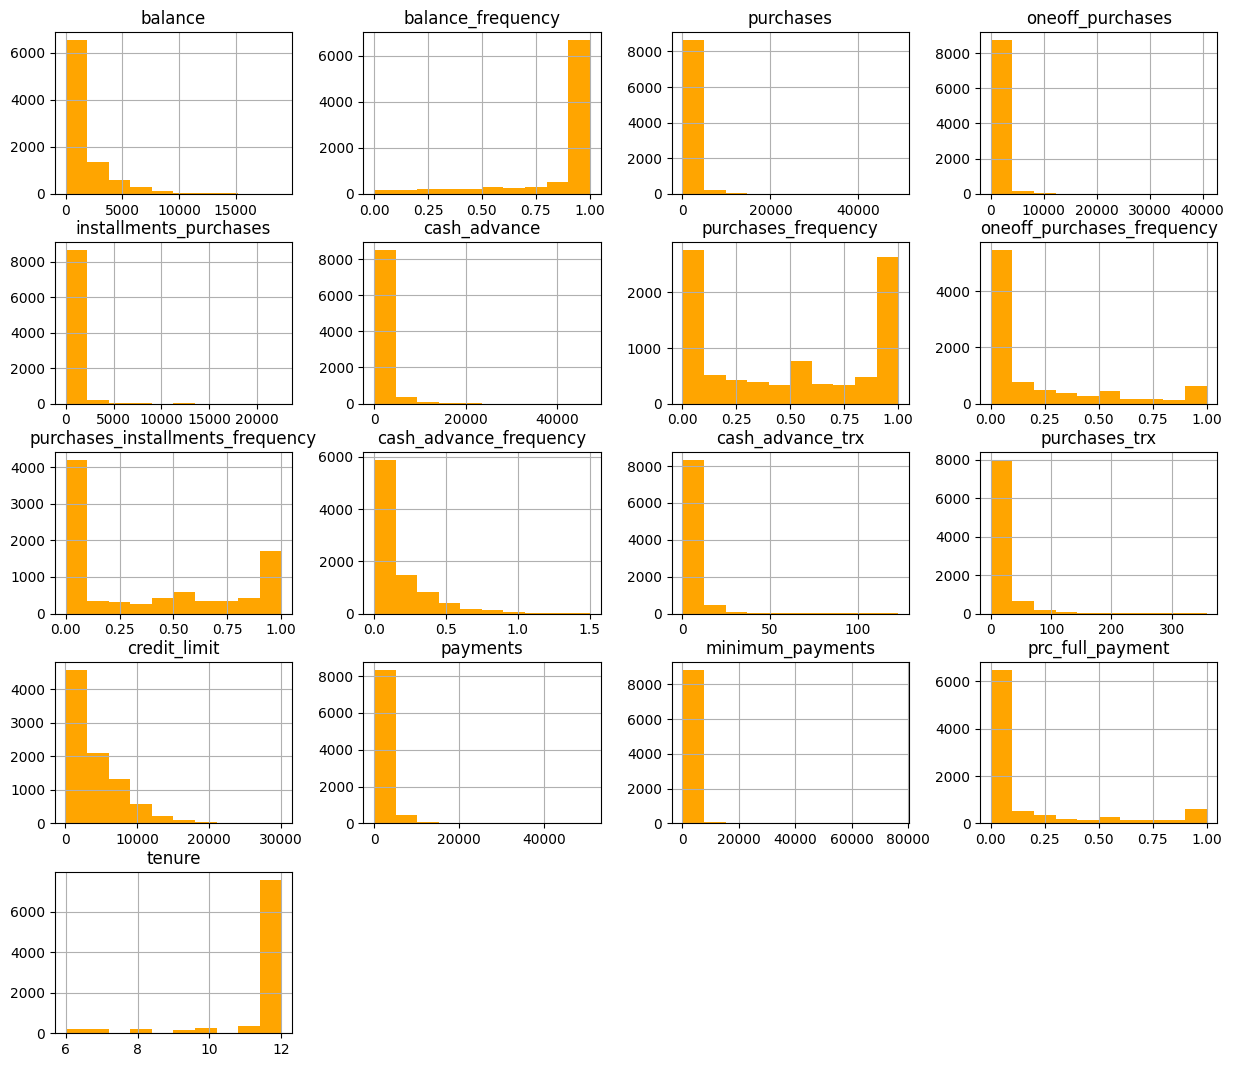

In [17]:
# Gerando o histograma pra entender como está as distribuições

df_credit_card.hist(bins=10, figsize=(15,13), facecolor = 'orange')

In [18]:
df_credit_card.columns

Index(['cust_id', 'balance', 'balance_frequency', 'purchases',
       'oneoff_purchases', 'installments_purchases', 'cash_advance',
       'purchases_frequency', 'oneoff_purchases_frequency',
       'purchases_installments_frequency', 'cash_advance_frequency',
       'cash_advance_trx', 'purchases_trx', 'credit_limit', 'payments',
       'minimum_payments', 'prc_full_payment', 'tenure',
       'null_minimum_payments'],
      dtype='str')

balance -> transformação logaritmica  
balance_frequency -> transformação quantil  
purchases -> transformação logaritmica  
oneoff_purchases -> transformação logaritmica  
installments_purchases -> transformação logaritmica  
cash_advance -> transformação logaritmica  
purchases_frequency -> transformação quantil  
oneoff_purchases_frequency -> transformação quantil  
purchases_installments_frequency -> transformação quantil  
cash_advance_frequency -> transformação logaritmica  
cash_advance_trx -> transformação logaritmica  
purchases_trx -> transformação logaritmica  
payments -> transformação logaritmica  
minimum_payments -> transformação logaritmica  
prc_full_payment -> transformação quantil  

In [19]:
# Criando lista das tranformacoes e variaveis q precisam ser transformadas
t_log = [
    'balance', 'purchases', 'oneoff_purchases', 'installments_purchases', 
    'cash_advance', 'cash_advance_frequency', 'cash_advance_trx', 'purchases_trx', 
    'credit_limit', 'payments', 'minimum_payments'
]

t_quantil = [
    'balance_frequency', 'purchases_frequency', 'oneoff_purchases_frequency', 
    'purchases_installments_frequency', 'prc_full_payment'
]